# Topic 14: Gymnasium and Q-Learning in Practice (CliffWalking)

Gymnasium is the standard RL environment library: dozens of environments behind ONE interface
(`make`, `reset`, `step`, `action_space`, `observation_space`). Our tabular Q-learning from
Topic 13 plugs straight into the discrete **Toy Text** environments. Here we meet the interface,
then run real experiments on the built-in **CliffWalking**.

## 1. The interface: a random agent

In [1]:
import gymnasium as gym, numpy as np, random

env = gym.make("CliffWalking-v1")
print("observation_space:", env.observation_space, " action_space:", env.action_space)
obs, info = env.reset(seed=0)
for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"action={action}  obs={obs:2d}  reward={reward}  done={terminated or truncated}")
env.close()

observation_space: Discrete(48)  action_space: Discrete(4)
action=0  obs=24  reward=-1  done=False
action=0  obs=12  reward=-1  done=False
action=2  obs=24  reward=-1  done=False
action=3  obs=24  reward=-1  done=False
action=1  obs=25  reward=-1  done=False


## 2. Q-learning on CliffWalking

States 0..47, actions 0..3, so `Q = np.zeros((48,4))` and the Topic-13 update is used verbatim. `epsilon` decays to 0 so the online return can reach the optimal -13.

In [2]:
def train(env_name, episodes, alpha=0.5, gamma=0.99, eps_min=0.0, decay=None,
          make_kwargs=None, cap=-10**9, seed=0, metric="return"):
    import gymnasium as gym, numpy as np, random
    random.seed(seed); np.random.seed(seed)
    env = gym.make(env_name, **(make_kwargs or {}))
    if decay is None: decay = episodes * 0.5
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    hist = np.empty(episodes)
    for ep in range(episodes):
        eps = max(eps_min, 1.0 - ep/decay)
        s,_ = env.reset(seed=seed*10000+ep); done=False; tot=0.0; last_r=0.0; t=0
        while not done and t < 200:
            a = env.action_space.sample() if random.random()<eps else int(np.argmax(Q[s]))
            s2,r,term,trunc,_ = env.step(a); done=term or trunc; tot+=r; last_r=r
            target = r + (0.0 if term else gamma*np.max(Q[s2]))   # only `terminated` cuts the bootstrap
            Q[s,a] += alpha*(target - Q[s,a]); s=s2; t+=1
        hist[ep] = max(tot, cap) if metric=="return" else last_r
    env.close()
    return hist, Q

In [3]:
returns, Q = train("CliffWalking-v1", episodes=500, alpha=0.5, decay=250, cap=-200, seed=0)
print("return over the last 50 episodes:", round(returns[-50:].mean(), 1), "(optimal -13)")

return over the last 50 episodes: -13.0 (optimal -13)


## 3. Does it learn? Average many runs with a std band

A single run is noisy; we plot the mean of 40 runs with a shaded +/- std band, the honest way to report an RL result.

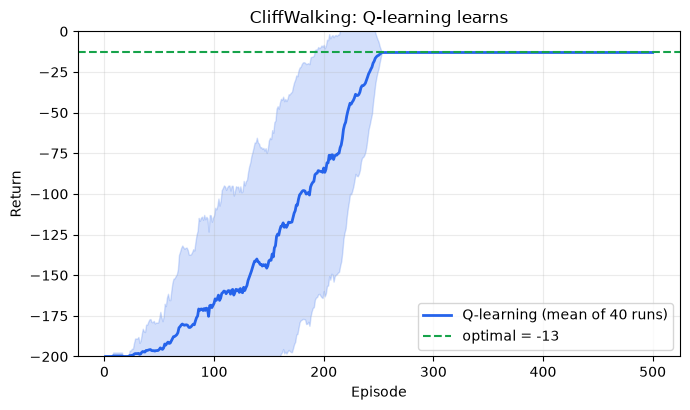

In [4]:
import matplotlib.pyplot as plt
def smooth(x,k=9):
    pad=np.concatenate([np.full(k//2,x[0]),x,np.full(k//2,x[-1])]); return np.convolve(pad,np.ones(k)/k,mode="valid")[:len(x)]
def many(seeds=40, **kw):
    R=np.stack([train(seed=i, **kw)[0] for i in range(seeds)]); return smooth(R.mean(0)), smooth(R.std(0))

EP=500; x=np.arange(1,EP+1)
m,s = many(env_name="CliffWalking-v1", episodes=EP, alpha=0.5, decay=250, cap=-200)
plt.figure(figsize=(7,4.2))
plt.plot(x,m,color="#2563eb",lw=2,label="Q-learning (mean of 40 runs)")
plt.fill_between(x,m-s,m+s,color="#2563eb",alpha=0.2)
plt.axhline(-13,color="#16a34a",ls="--",label="optimal = -13")
plt.ylim(-200,0); plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("CliffWalking: Q-learning learns")
plt.legend(loc="lower right"); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

## 4. Parameter sweep: the learning rate

Too small is slow, too large is noisy; the sweet spot depends on the problem.

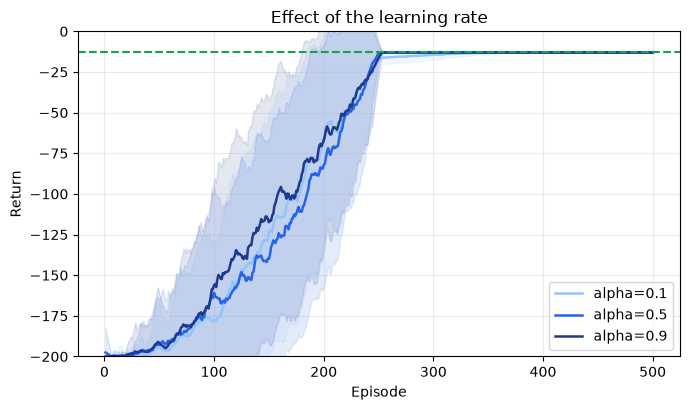

In [5]:
plt.figure(figsize=(7,4.2))
for a,col in [(0.1,"#93c5fd"),(0.5,"#2563eb"),(0.9,"#1e3a8a")]:
    m,s=many(env_name="CliffWalking-v1", episodes=EP, alpha=a, decay=250, cap=-200)
    plt.plot(x,m,color=col,lw=1.8,label=f"alpha={a}"); plt.fill_between(x,m-s,m+s,color=col,alpha=0.12)
plt.axhline(-13,color="#16a34a",ls="--"); plt.ylim(-200,0)
plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("Effect of the learning rate")
plt.legend(loc="lower right"); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Try it
- Change the string to another Toy Text env (`FrozenLake-v1`, `Taxi-v4`), the same code resizes itself.
- `CartPole-v1` will crash the table, its observation is 4 real numbers (infinitely many states). That needs function approximation: **Topic 18 (DQN)**.